In [1]:

# Core imports and notebook configuration

import os
import re
import math
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from textblob import TextBlob
from wordcloud import WordCloud
import networkx as nx

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)
plt.rcParams["figure.figsize"] = (10, 6)

# Download required NLTK resources (safe to run multiple times)
for pkg in ["punkt", "stopwords", "wordnet", "omw-1.4", "vader_lexicon"]:
    nltk.download(pkg, quiet=True)

lemmatizer = WordNetLemmatizer()
sia = SentimentIntensityAnalyzer()

OUTPUT_DIR = "cia4_outputs_final"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Working directory:", os.getcwd())
print("Output directory:", OUTPUT_DIR)


Working directory: c:\Text_Analytics\CIA3\main
Output directory: cia4_outputs_final


## 2. Load the Dataset


In [2]:

# Dataset path configuration
# Replace this with your actual dataset file name if auto-detection does not find it.

DATA_PATH = None

candidate_paths = [
    "subscription_churn_responses_form_format.xlsx",
    "TSMA CIA4.xlsx",
    "CIA4.xlsx"
]

# Auto-detect any xlsx in the current working directory
xlsx_files = sorted(Path(".").glob("*.xlsx"))
for p in candidate_paths:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None and xlsx_files:
    DATA_PATH = str(xlsx_files[0])

print("Detected DATA_PATH:", DATA_PATH)

if DATA_PATH is None:
    raise FileNotFoundError(
        "No Excel dataset found in the notebook folder. "
        "Place your .xlsx file in the same folder and rerun this cell."
    )

df = pd.read_excel(DATA_PATH)
print("Original shape:", df.shape)
display(df.head(3))


Detected DATA_PATH: subscription_churn_responses_form_format.xlsx
Original shape: (127, 9)


,Timestamp,Please enter your gender,Please enter your age,Please enter your monthly income range,"“Please share your detailed opinions about the following aspects of the subscription service. For each attribute, describe your experience and perception:”\nContent or Service Quality:\nHow satisfied were you with the quality, usefulness, or relevance of the service provided?\nPricing & Value for Money:\nDid you feel the subscription price matched the value you received?\nUser Experience & Convenience:\nHow easy was it to use the platform or access the service?\nCustomer Support:\nWhat was your experience with customer service or issue resolution?\nFeatures & Innovation:\nDid the service offer enough features or improvements to keep you engaged?","“Please share your detailed opinions about the following aspects of the subscription service. For each attribute, describe your experience and perception:”\nContent or Service Quality:\nHow satisfied were you with the quality, usefulness, or relevance of the service provided?\nPricing & Value for Money:\nDid you feel the subscription price matched the value you received?\nUser Experience & Convenience:\nHow easy was it to use the platform or access the service?\nCustomer Support:\nWhat was your experience with customer service or issue resolution?\nFeatures & Innovation:\nDid the service offer enough features or improvements to keep you engaged?.1","“Please describe how you used the subscription service during the time you were subscribed.\nFor example:\nHow frequently did you use the service?\nIn what situations or contexts did you find it most useful?\nDid your usage change over time? If so, explain why.\nIf your usage declined before cancellation, please describe what caused this change.”","“Before cancelling the subscription, were there any warning signs or frustrations that made you feel dissatisfied with the service?\nPlease describe any specific pain points you experienced, such as:\nPoor service quality\nTechnical issues or usability problems\nHigh pricing\nLack of relevant content or features\nBetter alternatives available\nReduced personal need for the service\nExplain how these issues influenced your decision to cancel.”","“Subscriptions often create emotional or functional connections with users.\nPlease describe how you felt about the service before cancelling it. For example, did you feel satisfied, indifferent, frustrated, disappointed, or something else?\nAdditionally:\nWould you consider returning to this subscription in the future? Why or why not?\nWhat changes or improvements would make you reconsider using the service again?\nIf possible, describe your experience as a short story of your journey with the service — from when you first subscribed to the moment you decided to cancel.”"
0,2026-05-03 08:14:22,Male,39,"₹80,000–₹1,20,000",I remember subscribing to Coursera since many of my friends recommended it. Eventually I decided the cost was not worth the value I was getting.,"If I break it down: the service quality was okay overall. Pricing was the main concern for me. The app design was simple enough to use daily. I didn't interact much with support, but innovation on...",At first it became part of my daily routine. Later my usage dropped because work became busy.,The turning point came after noticing some consistent problems. The platform sometimes felt repetitive and predictable. That gradually influenced my decision to cancel the subscription.,"From an emotional perspective, initially I was quite satisfied. A better value plan could definitely bring me back."
1,2026-05-03 08:57:31,Male,34,"₹80,000–₹1,20,000",At one point I was actively using a cloud storage plan as part of a trial offer. Gradually I lost interest and cancelled it.,"Regarding quality, it was decent but not outstanding. Pricing felt slightly high from an Indian perspective. The interface itself was fairly easy to navigate, although I noticed occasional lag. Cu...",In the beginning I used it quite fre

In [3]:

# Rename columns for convenience if the expected survey format is detected

expected_cols = [
    "timestamp",
    "gender",
    "age",
    "income",
    "overall_experience",
    "service_attribute_evaluation",
    "usage_context",
    "pain_points",
    "emotional_loyalty_future"
]

if len(df.columns) == len(expected_cols):
    df.columns = expected_cols
    print("Columns renamed to simplified labels.")
else:
    print("Column count differs from expected format.")
    print("Review raw column names manually below:")
    display(pd.DataFrame({"raw_columns": df.columns}))


Columns renamed to simplified labels.


In [4]:

# Basic audit

audit = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing_values": [df[c].isna().sum() for c in df.columns],
    "non_null_values": [df[c].notna().sum() for c in df.columns],
    "unique_values": [df[c].nunique(dropna=True) for c in df.columns]
})

display(audit)


,column,dtype,missing_values,non_null_values,unique_values
0,timestamp,datetime64[us],0,127,127
1,gender,str,0,127,4
2,age,int64,0,127,42
3,income,str,0,127,5
4,overall_experience,str,0,127,123
5,service_attribute_evaluation,str,0,127,4
6,usage_context,str,0,127,25
7,pain_points,str,0,127,25
8,emotional_loyalty_future,str,0,127,65


In [5]:

# Clean key fields and create a combined text column

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

if "age" in df.columns:
    df["age"] = pd.to_numeric(df["age"], errors="coerce")

text_cols = [
    c for c in [
        "overall_experience",
        "service_attribute_evaluation",
        "usage_context",
        "pain_points",
        "emotional_loyalty_future"
    ] if c in df.columns
]

if not text_cols:
    raise ValueError("No expected text columns found. Review the dataset schema before proceeding.")

for col in text_cols:
    df[col] = df[col].fillna("").astype(str).str.strip()

df["combined_text"] = df[text_cols].agg(" ".join, axis=1)
df["combined_text"] = df["combined_text"].str.replace(r"\s+", " ", regex=True).str.strip()

print("Final shape:", df.shape)
print("Duplicate combined responses:", df["combined_text"].duplicated().sum())
display(df[["combined_text"]].head(3))


Final shape: (127, 10)
Duplicate combined responses: 0


,combined_text
0,I remember subscribing to Coursera since many of my friends recommended it. Eventually I decided the cost was not worth the value I was getting. If I break it down: the service quality was okay ov...
1,"At one point I was actively using a cloud storage plan as part of a trial offer. Gradually I lost interest and cancelled it. Regarding quality, it was decent but not outstanding. Pricing felt slig..."
2,I remember subscribing to a cloud storage plan because I thought it would become part of my routine. Gradually I lost interest and cancelled it. If I break it down: the service quality was okay ov...


## 3. Demographic Overview


,count
gender,
Male,35
Female,34
Non-binary,33
Prefer not to say,25


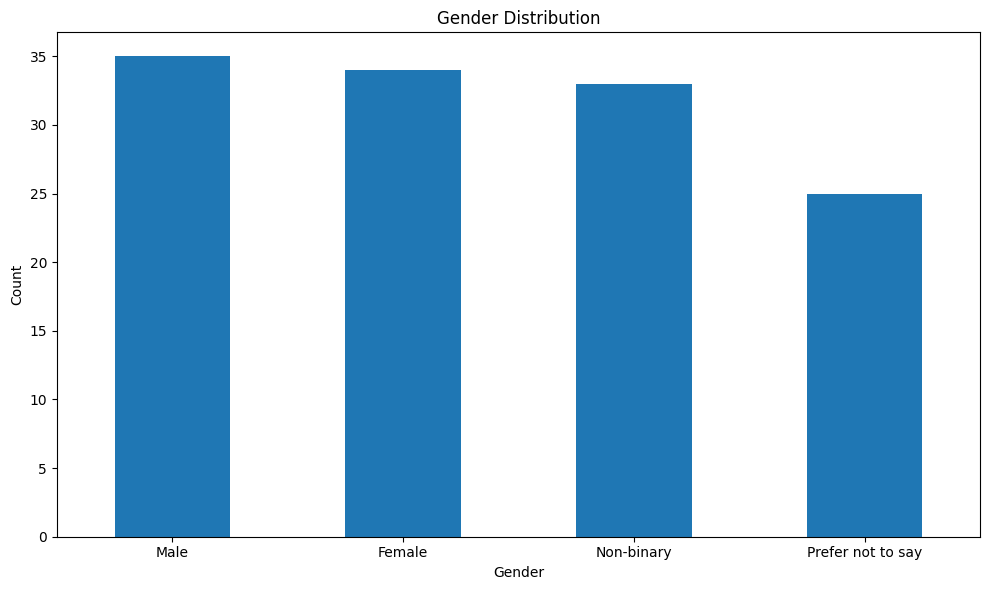

In [6]:

# Gender distribution

if "gender" in df.columns:
    gender_counts = df["gender"].fillna("Missing").value_counts()
    display(gender_counts.to_frame("count"))

    plt.figure()
    gender_counts.plot(kind="bar")
    plt.title("Gender Distribution")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'gender' not found.")


count    127.000000
mean      38.771654
std       14.724016
min       18.000000
25%       25.500000
50%       37.000000
75%       52.500000
max       65.000000
Name: age, dtype: float64

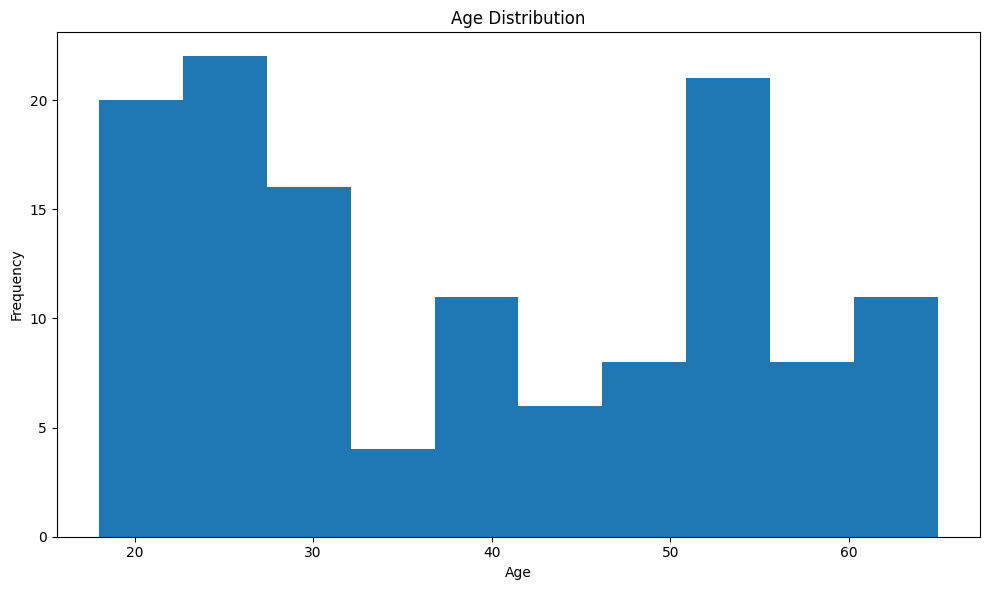

In [7]:

# Age distribution

if "age" in df.columns:
    display(df["age"].describe())

    plt.figure()
    df["age"].dropna().plot(kind="hist", bins=10)
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'age' not found.")


,count
income,
"₹80,000–₹1,20,000",38
"₹25,000–₹50,000",28
"Above ₹1,20,000",26
"₹50,000–₹80,000",19
"Below ₹25,000",16


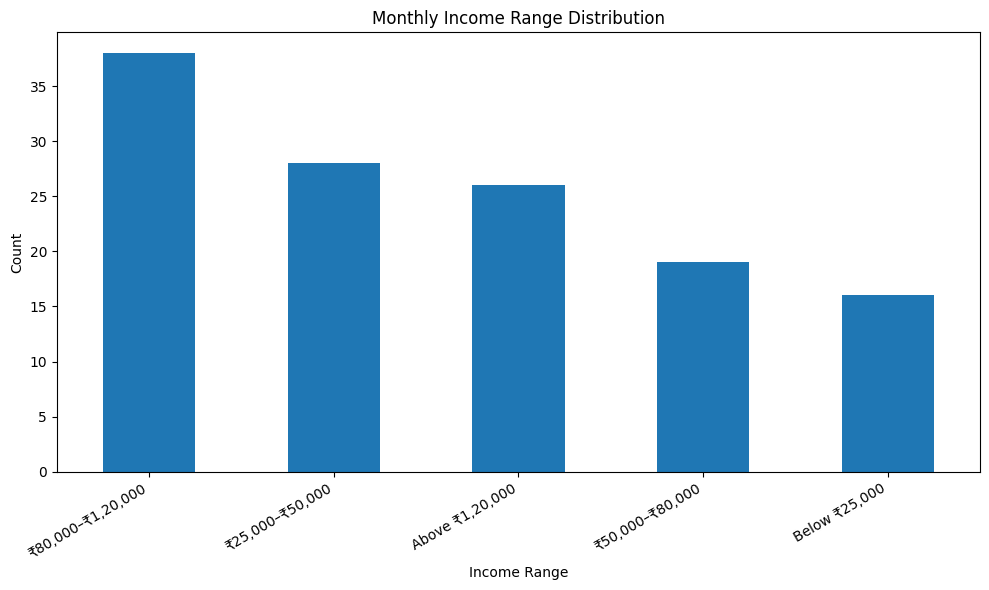

In [8]:

# Income distribution

if "income" in df.columns:
    income_counts = df["income"].fillna("Missing").value_counts()
    display(income_counts.to_frame("count"))

    plt.figure()
    income_counts.plot(kind="bar")
    plt.title("Monthly Income Range Distribution")
    plt.xlabel("Income Range")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'income' not found.")


## 4. Text Preprocessing


In [9]:

# Best-of-both-worlds preprocessing:
# - sklearn + NLTK stopwords
# - domain stopwords
# - tokenization
# - lemmatization
# - regex cleaning

base_stopwords = set(ENGLISH_STOP_WORDS).union(set(stopwords.words("english")))

domain_stopwords = {
    "subscription", "service", "cancel", "cancelled", "cancelling", "overall",
    "experience", "please", "describe", "aspect", "aspects", "customer", "customers",
    "platform", "company", "content", "support", "user", "users", "using", "used", "use",
    "feel", "felt", "would", "could", "also", "really", "quite", "still", "one",
    "get", "got", "make", "made", "thing", "things",
    "month", "monthly", "plan", "plans", "app"
}

STOPWORDS = base_stopwords.union(domain_stopwords)

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = nltk.word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok.isalpha() and tok not in STOPWORDS and len(tok) > 2
    ]
    return " ".join(tokens)

df["clean_text"] = df["combined_text"].apply(clean_text)
df["word_count"] = df["clean_text"].str.split().str.len()

analysis_df = df[df["clean_text"].str.len() > 0].copy()

print("Rows available for analysis:", len(analysis_df))
display(analysis_df[["combined_text", "clean_text", "word_count"]].head(5))


Rows available for analysis: 127


,combined_text,clean_text,word_count
0,I remember subscribing to Coursera since many of my friends recommended it. Eventually I decided the cost was not worth the value I was getting. If I break it down: the service quality was okay ov...,remember subscribing coursera friend recommended eventually decided cost worth value getting break quality okay pricing main concern design simple daily interact innovation limited daily routine l...,49
1,"At one point I was actively using a cloud storage plan as part of a trial offer. Gradually I lost interest and cancelled it. Regarding quality, it was decent but not outstanding. Pricing felt slig...",point actively cloud storage trial offer gradually lost regarding quality decent outstanding pricing slightly high indian perspective interface fairly easy navigate noticed occasional lag polite s...,54
2,I remember subscribing to a cloud storage plan because I thought it would become part of my routine. Gradually I lost interest and cancelled it. If I break it down: the service quality was okay ov...,remember subscribing cloud storage thought routine gradually lost break quality okay pricing main concern design simple daily interact innovation limited week active slowly realised barely turning...,47
3,"The subscription I cancelled recently was a meditation app mainly out of curiosity. Over time I realised I wasn't using it enough to justify paying every month. From my point of view, the platform...",recently meditation mainly curiosity time realised justify paying point view worked fine technically price justified navigation inside smooth update new feature rare week active slowly realised ba...,42
4,"My experience with Coursera as part of a trial offer. After a few months it started feeling unnecessary. From my point of view, the platform worked fine technically. However, the monthly price did...",coursera trial offer month started feeling unnecessary point view worked fine technically price justified navigation inside smooth update new feature rare week active gradually stopped opening thi...,45


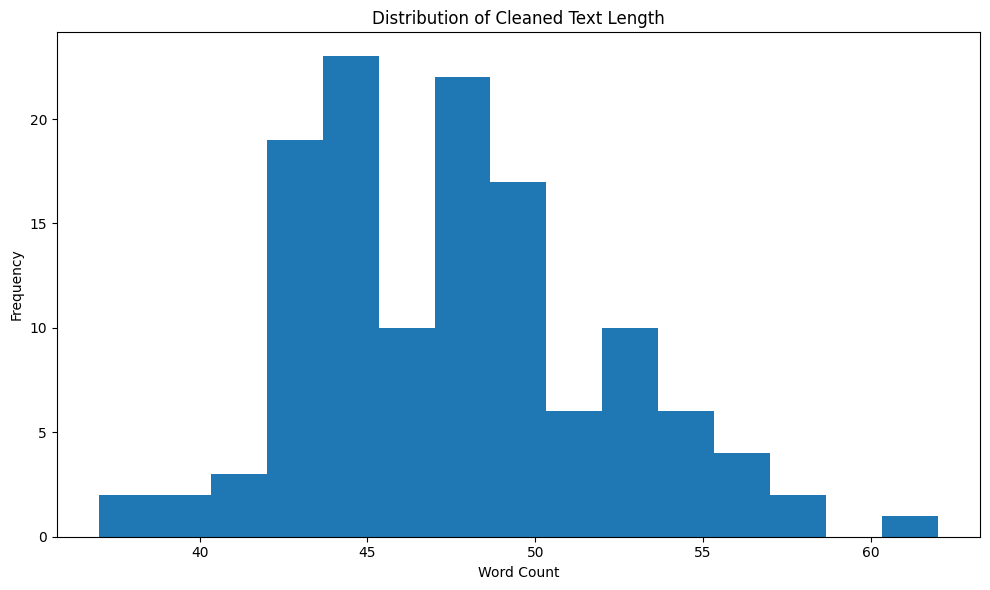

In [10]:

# Distribution of cleaned text length

plt.figure()
analysis_df["word_count"].plot(kind="hist", bins=15)
plt.title("Distribution of Cleaned Text Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 5. Exploratory Text Analysis


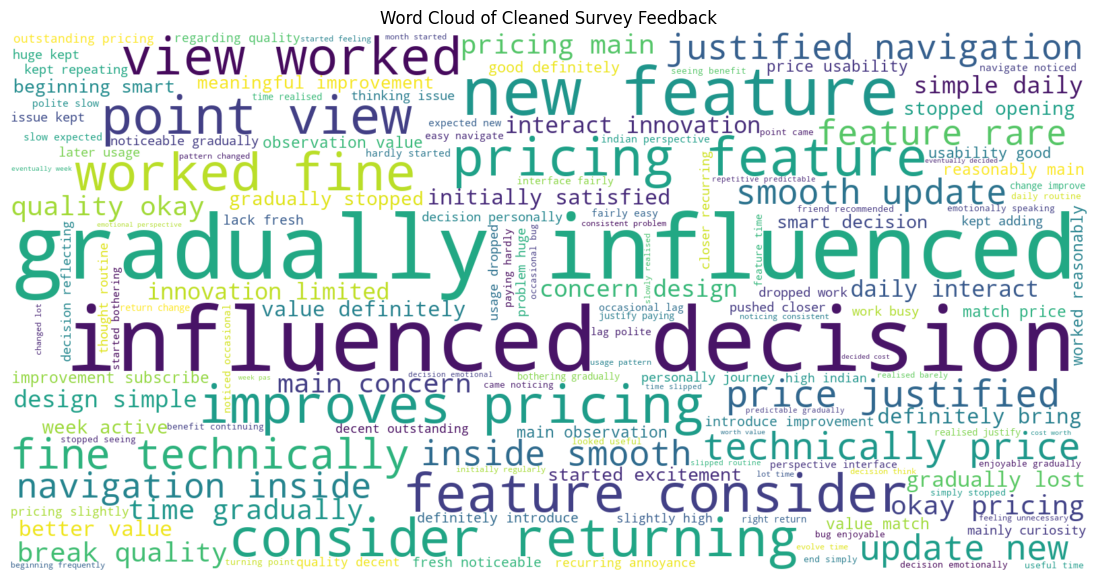

In [11]:

# Word cloud

all_text = " ".join(analysis_df["clean_text"].tolist())

wc = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    max_words=150
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Survey Feedback")
plt.show()


In [12]:

# Helper function for top n-grams

def top_ngrams(text_series, ngram_range=(1, 1), top_n=20, min_df=2):
    vectorizer = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    X = vectorizer.fit_transform(text_series)
    frequencies = np.asarray(X.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    out = pd.DataFrame({"term": terms, "frequency": frequencies})
    out = out.sort_values("frequency", ascending=False).head(top_n).reset_index(drop=True)
    return out

top_unigrams = top_ngrams(analysis_df["clean_text"], (1, 1), top_n=20, min_df=2)
top_bigrams = top_ngrams(analysis_df["clean_text"], (2, 2), top_n=20, min_df=2)
top_trigrams = top_ngrams(analysis_df["clean_text"], (3, 3), top_n=20, min_df=2)

display(top_unigrams)
display(top_bigrams.head(10))
display(top_trigrams.head(10))


,term,frequency
0,gradually,194
1,decision,160
2,time,146
3,influenced,127
4,feature,99
5,pricing,97
6,started,95
7,value,83
8,point,76
9,routine,75


,term,frequency
0,influenced decision,127
1,gradually influenced,127
2,new feature,62
3,feature consider,37
4,consider returning,37
5,improves pricing,37
6,pricing feature,37
7,smooth update,36
8,inside smooth,36
9,technically price,36


,term,frequency
0,gradually influenced decision,127
1,feature consider returning,37
2,pricing feature consider,37
3,improves pricing feature,37
4,view worked fine,36
5,update new feature,36
6,price justified navigation,36
7,fine technically price,36
8,navigation inside smooth,36
9,point view worked,36


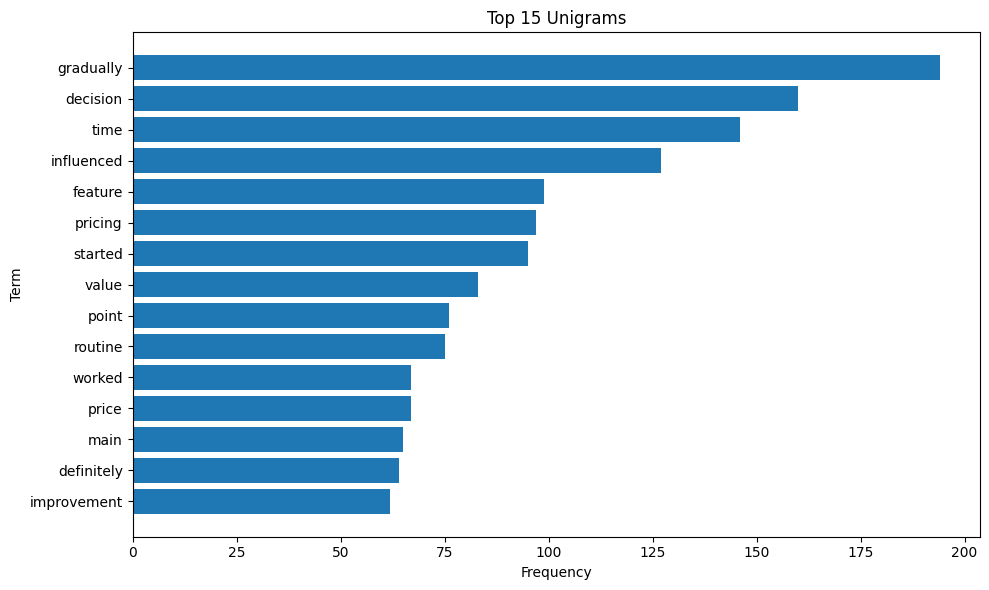

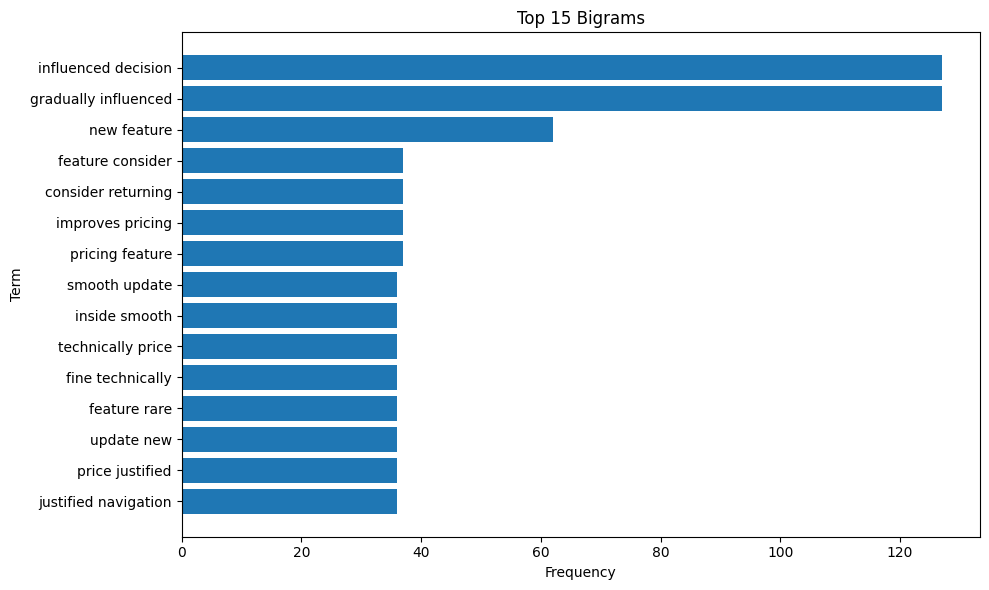

In [13]:

# Plot top terms

def plot_top_terms(df_terms, title):
    plt.figure(figsize=(10, 6))
    plt.barh(df_terms["term"][::-1], df_terms["frequency"][::-1])
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Term")
    plt.tight_layout()
    plt.show()

plot_top_terms(top_unigrams.head(15), "Top 15 Unigrams")
plot_top_terms(top_bigrams.head(15), "Top 15 Bigrams")


## 6. Sentiment Analysis


,count
sentiment_label,
Positive,115
Negative,9
Neutral,3


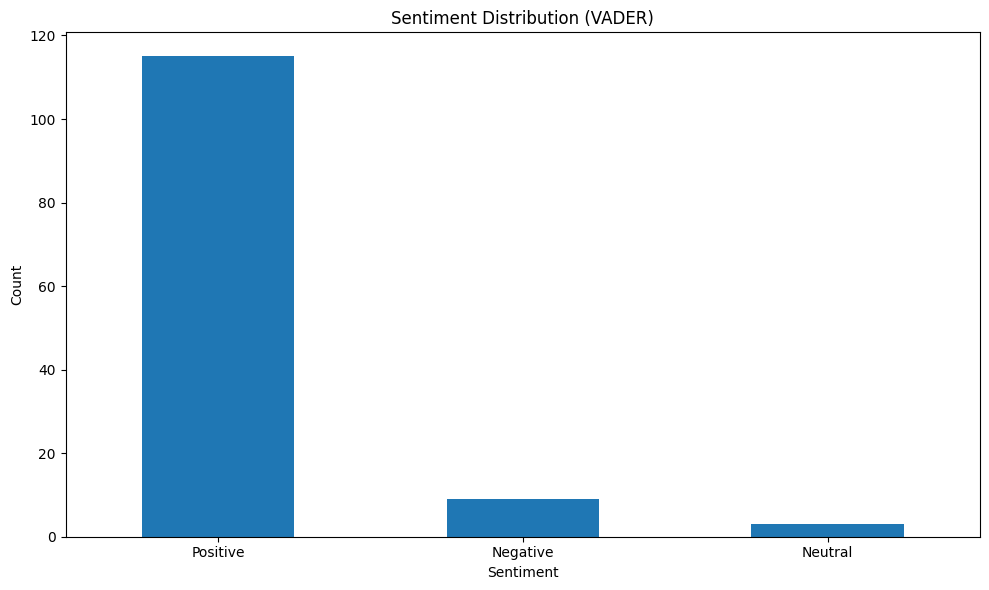

In [14]:

# VADER sentiment (primary sentiment method)

analysis_df["vader_compound"] = analysis_df["combined_text"].astype(str).apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

def vader_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    return "Neutral"

analysis_df["sentiment_label"] = analysis_df["vader_compound"].apply(vader_label)

sentiment_counts = analysis_df["sentiment_label"].value_counts()
display(sentiment_counts.to_frame("count"))

plt.figure()
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution (VADER)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [15]:

# TextBlob sentiment (supporting polarity measure)

analysis_df["textblob_polarity"] = analysis_df["combined_text"].astype(str).apply(
    lambda x: TextBlob(x).sentiment.polarity
)
analysis_df["textblob_subjectivity"] = analysis_df["combined_text"].astype(str).apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)

display(
    analysis_df[
        ["combined_text", "vader_compound", "sentiment_label", "textblob_polarity", "textblob_subjectivity"]
    ].head(10)
)


,combined_text,vader_compound,sentiment_label,textblob_polarity,textblob_subjectivity
0,I remember subscribing to Coursera since many of my friends recommended it. Eventually I decided the cost was not worth the value I was getting. If I break it down: the service quality was okay ov...,0.8272,Positive,0.089153,0.300231
1,"At one point I was actively using a cloud storage plan as part of a trial offer. Gradually I lost interest and cancelled it. Regarding quality, it was decent but not outstanding. Pricing felt slig...",-0.5481,Negative,0.048091,0.542414
2,I remember subscribing to a cloud storage plan because I thought it would become part of my routine. Gradually I lost interest and cancelled it. If I break it down: the service quality was okay ov...,0.8144,Positive,0.040246,0.340831
3,"The subscription I cancelled recently was a meditation app mainly out of curiosity. Over time I realised I wasn't using it enough to justify paying every month. From my point of view, the platform...",0.5118,Positive,0.091818,0.456061
4,"My experience with Coursera as part of a trial offer. After a few months it started feeling unnecessary. From my point of view, the platform worked fine technically. However, the monthly price did...",0.8131,Positive,0.092266,0.458716
5,"I had signed up for an online learning platform because it looked useful at the time. Eventually I decided the cost was not worth the value I was getting. Regarding quality, it was decent but not ...",-0.3580,Negative,0.041465,0.410808
6,At one point I was actively using Cult Fit as part of a trial offer. In the end I simply stopped seeing the benefit of continuing. If I break it down: the service quality was okay overall. Pricing...,0.7430,Positive,0.075317,0.314563
7,For a while I depended on YouTube Premium as part of a trial offer. Over time I realised I wasn't using it enough to justify paying every month. The service itself worked reasonably well. My main ...,0.9659,Positive,0.148880,0.382423
8,For a while I depended on a news subscription as part of a trial offer. In the end I simply stopped seeing the benefit of continuing. If I break it down: the service quality was okay overall. Pric...,0.9116,Positive,0.050699,0.316875
9,When I first tried YouTube Premium as part of a trial offer. In the end I simply stopped seeing the benefit of continuing. The service itself worked reasonably well. My main observation was that t...,0.8955,Positive,0.210159,0.416190


In [16]:

# Review sample responses from each sentiment bucket

for label in analysis_df["sentiment_label"].unique():
    print("\n" + "=" * 100)
    print("SENTIMENT:", label)
    subset = analysis_df.loc[analysis_df["sentiment_label"] == label, "combined_text"].head(2).tolist()
    for i, txt in enumerate(subset, 1):
        print(f"\nExample {i}:")
        print(txt[:800], "...")



SENTIMENT: Positive

Example 1:
I remember subscribing to Coursera since many of my friends recommended it. Eventually I decided the cost was not worth the value I was getting. If I break it down: the service quality was okay overall. Pricing was the main concern for me. The app design was simple enough to use daily. I didn't interact much with support, but innovation on the platform felt limited. At first it became part of my daily routine. Later my usage dropped because work became busy. The turning point came after noticing some consistent problems. The platform sometimes felt repetitive and predictable. That gradually influenced my decision to cancel the subscription. From an emotional perspective, initially I was quite satisfied. A better value plan could definitely bring me back. ...

Example 2:
I remember subscribing to a cloud storage plan because I thought it would become part of my routine. Gradually I lost interest and cancelled it. If I break it down: the service quality w

## 7. Topic Modeling (LDA)


In [17]:

# LDA topic modeling on cleaned text

NUM_TOPICS = 5
TOP_WORDS = 10

lda_vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words="english")
lda_X = lda_vectorizer.fit_transform(analysis_df["clean_text"])

lda_model = LatentDirichletAllocation(
    n_components=NUM_TOPICS,
    random_state=42,
    learning_method="batch"
)
lda_model.fit(lda_X)

feature_names = lda_vectorizer.get_feature_names_out()

def get_topic_terms(model, feature_names, n_top_words=10):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_features = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics[f"Topic {topic_idx + 1}"] = top_features
    return topics

topics = get_topic_terms(lda_model, feature_names, TOP_WORDS)
topics_df = pd.DataFrame({
    "topic": list(topics.keys()),
    "top_words": [", ".join(v) for v in topics.values()]
})

display(topics_df)


,topic,top_words
0,Topic 1,"time, changed, lot, pattern, usage, recurring, closer, annoyance, pushed, value"
1,Topic 2,"pricing, daily, interact, concern, design, simple, innovation, break, limited, okay"
2,Topic 3,"time, price, worked, feature, improvement, stopped, routine, point, value, definitely"
3,Topic 4,"time, occasional, pricing, feature, perspective, high, interface, decent, slightly, polite"
4,Topic 5,"value, started, point, usage, definitely, worked, price, busy, dropped, later"


,count
dominant_topic,
1,2
2,30
3,48
4,24
5,23


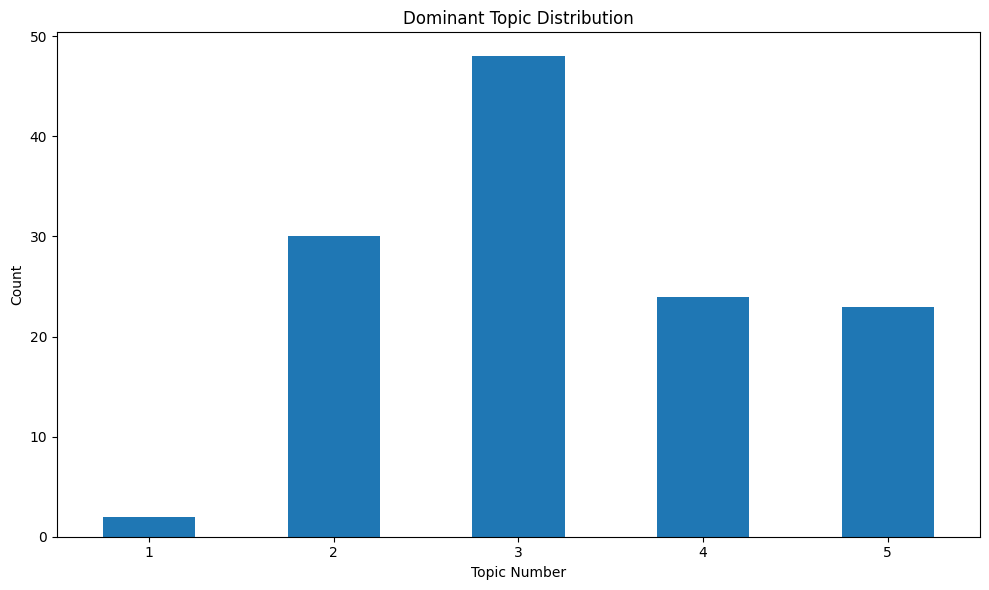

In [18]:

# Assign dominant topic to each response

topic_probabilities = lda_model.transform(lda_X)
analysis_df["dominant_topic"] = topic_probabilities.argmax(axis=1) + 1

topic_distribution = analysis_df["dominant_topic"].value_counts().sort_index()
display(topic_distribution.to_frame("count"))

plt.figure()
topic_distribution.plot(kind="bar")
plt.title("Dominant Topic Distribution")
plt.xlabel("Topic Number")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [19]:

# Show sample responses by topic

for topic_num in sorted(analysis_df["dominant_topic"].unique()):
    print("\n" + "=" * 100)
    print(f"TOPIC {topic_num}")
    print("Keywords:", topics_df.loc[topics_df["topic"] == f"Topic {topic_num}", "top_words"].iloc[0])
    sample_texts = analysis_df.loc[analysis_df["dominant_topic"] == topic_num, "combined_text"].head(2).tolist()
    for i, txt in enumerate(sample_texts, 1):
        print(f"\nExample {i}:")
        print(txt[:800], "...")



TOPIC 1
Keywords: time, changed, lot, pattern, usage, recurring, closer, annoyance, pushed, value

Example 1:
I had signed up for an online learning platform because it looked useful at the time. Eventually I decided the cost was not worth the value I was getting. Regarding quality, it was decent but not outstanding. Pricing felt slightly high from an Indian perspective. The interface itself was fairly easy to navigate, although I noticed occasional lag. Customer support was polite but slow, and I expected more new features over time. My usage pattern changed a lot over time. But gradually I stopped opening the app as often. What pushed me closer to cancelling were a few recurring annoyances. The platform sometimes felt repetitive and predictable. That gradually influenced my decision to cancel the subscription. From an emotional perspective, I was optimistic about the service. A better value plan ...

Example 2:
I originally subscribed to a news subscription since many of my friends 

## 8. Social Network Analysis


,beginning,consider,daily,decision,definitely,eventually,feature,fine,gradually,improvement,...,started,stopped,technically,time,update,usage,value,view,week,worked
beginning,0,18,23,93,26,17,42,15,93,28,...,31,29,15,54,15,22,34,15,22,29
consider,18,0,17,50,10,8,54,10,59,10,...,32,23,10,52,10,14,14,10,13,20
daily,23,17,0,72,19,16,33,10,88,13,...,44,32,10,54,10,19,27,10,17,13
decision,93,50,72,0,77,49,127,48,248,81,...,111,77,48,182,48,64,100,48,72,88
definitely,26,10,19,77,0,27,23,7,98,48,...,49,29,7,59,7,22,95,7,33,47


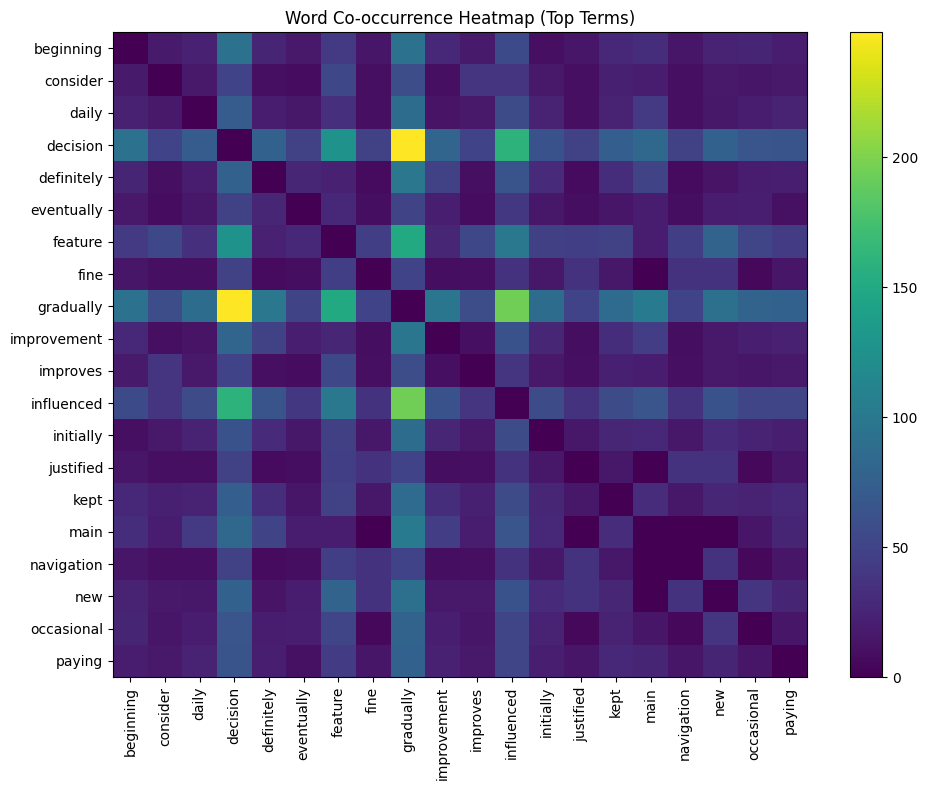

In [20]:

# Co-occurrence matrix and heatmap

co_vectorizer = CountVectorizer(max_features=40, stop_words="english")
co_X = co_vectorizer.fit_transform(analysis_df["clean_text"])
co_occ_matrix = (co_X.T @ co_X)
co_occ_matrix.setdiag(0)

co_terms = co_vectorizer.get_feature_names_out()
co_df = pd.DataFrame(co_occ_matrix.toarray(), index=co_terms, columns=co_terms)

display(co_df.head())

plt.figure(figsize=(10, 8))
plt.imshow(co_df.iloc[:20, :20], aspect="auto")
plt.colorbar()
plt.title("Word Co-occurrence Heatmap (Top Terms)")
plt.xticks(range(min(20, len(co_df.columns))), co_df.columns[:20], rotation=90)
plt.yticks(range(min(20, len(co_df.index))), co_df.index[:20])
plt.tight_layout()
plt.show()


In [21]:

# Co-occurrence network from top unigrams

top_terms_for_network = set(top_unigrams.head(25)["term"])

def get_cooccurrence_edges(text, vocab):
    tokens = [t for t in text.split() if t in vocab]
    unique_tokens = list(dict.fromkeys(tokens))
    edges = []
    for i in range(len(unique_tokens)):
        for j in range(i + 1, len(unique_tokens)):
            edges.append((unique_tokens[i], unique_tokens[j]))
    return edges

edge_counter = Counter()
for txt in analysis_df["clean_text"]:
    edge_counter.update(get_cooccurrence_edges(txt, top_terms_for_network))

G = nx.Graph()
for (a, b), weight in edge_counter.items():
    if weight >= 3:
        G.add_edge(a, b, weight=weight)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Nodes: 20
Edges: 187


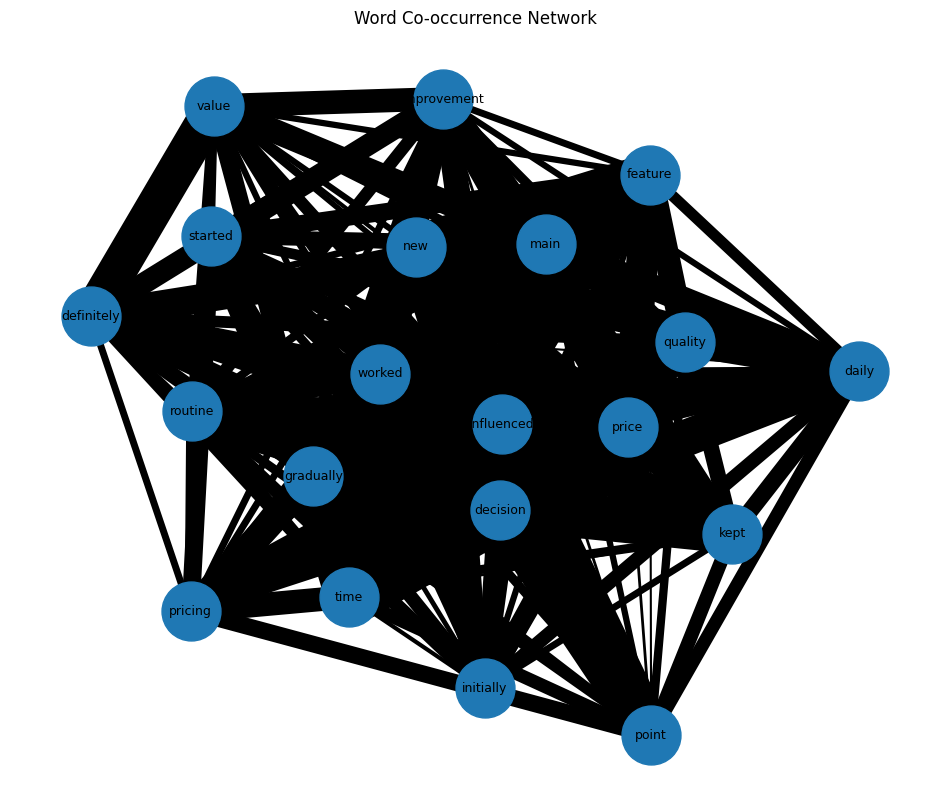

In [22]:

# Plot the co-occurrence network

plt.figure(figsize=(12, 10))

if G.number_of_nodes() > 0:
    pos = nx.spring_layout(G, k=0.8, seed=42)
    edge_widths = [G[u][v]["weight"] / 2 for u, v in G.edges()]
    nx.draw_networkx(
        G,
        pos=pos,
        with_labels=True,
        node_size=1800,
        font_size=9,
        width=edge_widths
    )
    plt.title("Word Co-occurrence Network")
    plt.axis("off")
    plt.show()
else:
    print("No network graph created. Lower the edge-weight threshold if needed.")


## 9. Clustering


In [23]:

# TF-IDF matrix for clustering and classification

tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=2)
X_tfidf = tfidf.fit_transform(analysis_df["clean_text"])

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (127, 572)


,k,silhouette_score
0,2,0.084898
1,3,0.111906
2,4,0.142172
3,5,0.113301
4,6,0.092030


Best k based on silhouette score: 4


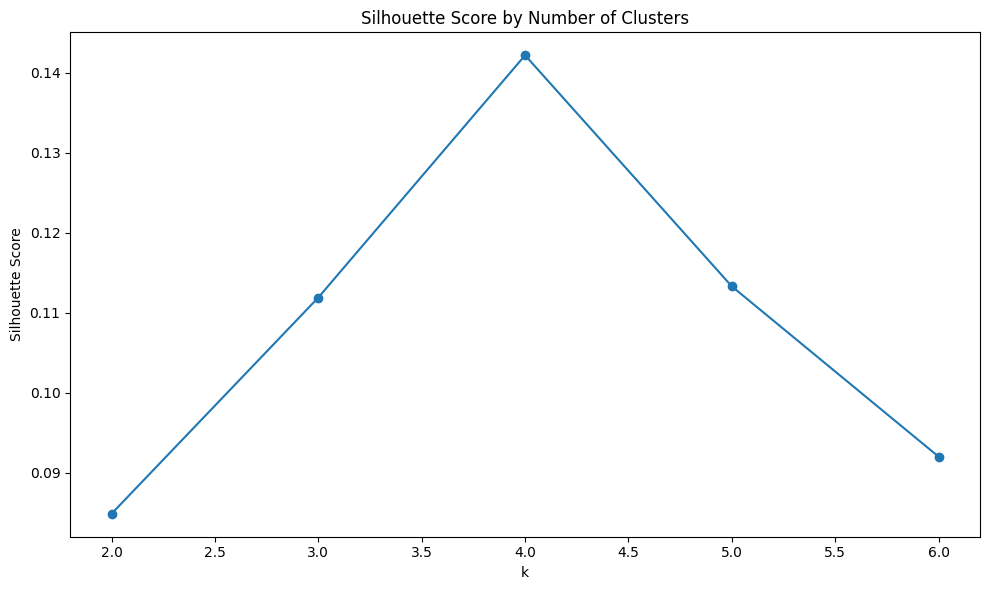

In [24]:

# Evaluate KMeans across different values of k using silhouette score

candidate_k = range(2, 7)
silhouette_scores = []

for k in candidate_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_tfidf)
    score = silhouette_score(X_tfidf, labels)
    silhouette_scores.append((k, score))

silhouette_df = pd.DataFrame(silhouette_scores, columns=["k", "silhouette_score"])
display(silhouette_df)

best_k = int(silhouette_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
print("Best k based on silhouette score:", best_k)

plt.figure()
plt.plot(silhouette_df["k"], silhouette_df["silhouette_score"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()


In [25]:

# Fit final clustering model and inspect cluster keywords

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
analysis_df["cluster"] = kmeans.fit_predict(X_tfidf)

terms = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

cluster_keywords = {}
for i in range(best_k):
    cluster_keywords[i] = [terms[ind] for ind in order_centroids[i, :12]]

cluster_keywords_df = pd.DataFrame({
    "cluster": list(cluster_keywords.keys()),
    "keywords": [", ".join(v) for v in cluster_keywords.values()]
})

display(cluster_keywords_df)

cluster_counts = analysis_df["cluster"].value_counts().sort_index()
display(cluster_counts.to_frame("count"))


,cluster,keywords
0,0,"time, easy, easy navigate, decent outstanding, decent, expected new, fairly, fairly easy, expected, slow expected, slow, feature time"
1,1,"value, usability, usability good, good definitely, definitely introduce, reasonably main, observation, main observation, match, observation value, reasonably, worked reasonably"
2,2,"point, update, technically, technically price, feature rare, update new, inside, navigation inside, navigation, view, rare, worked fine"
3,3,"break quality, break, concern, concern design, innovation limited, simple, innovation, design simple, design, daily interact, interact, simple daily"


,count
cluster,
0,26
1,31
2,36
3,34


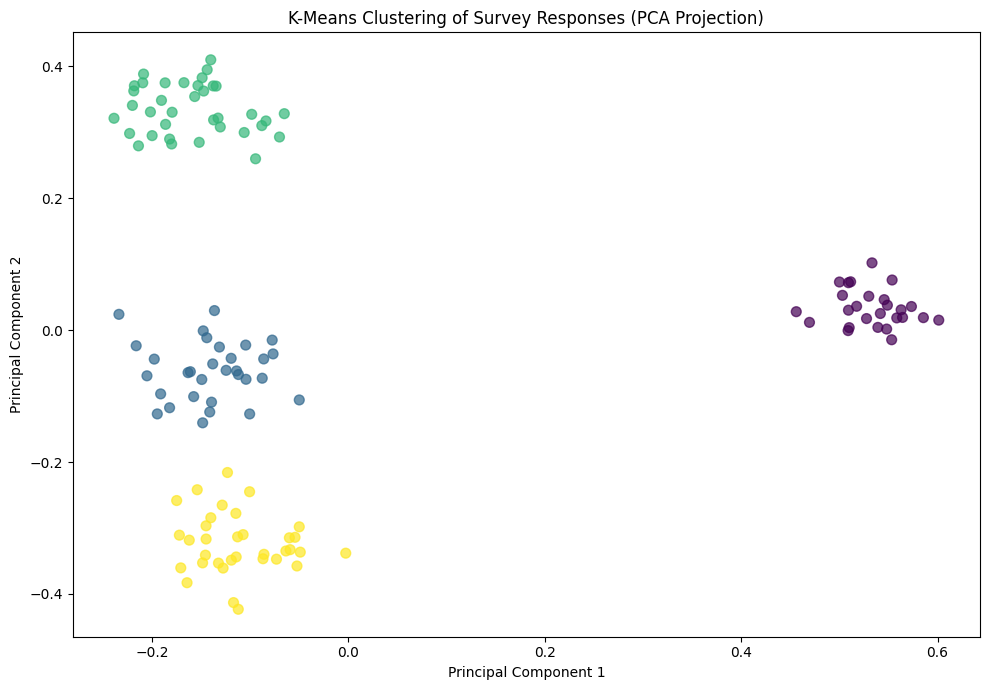

In [26]:

# PCA visualization of clusters (borrowed from the senior notebook idea)

pca = PCA(n_components=2, random_state=42)
X_reduced = pca.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(10, 7))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=analysis_df["cluster"], s=50, alpha=0.7)
plt.title("K-Means Clustering of Survey Responses (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()


In [27]:

# Sample responses by cluster

for cluster_id in sorted(analysis_df["cluster"].unique()):
    print("\n" + "=" * 100)
    print(f"CLUSTER {cluster_id}")
    print("Keywords:", cluster_keywords_df.loc[cluster_keywords_df["cluster"] == cluster_id, "keywords"].iloc[0])
    sample_texts = analysis_df.loc[analysis_df["cluster"] == cluster_id, "combined_text"].head(2).tolist()
    for i, txt in enumerate(sample_texts, 1):
        print(f"\nExample {i}:")
        print(txt[:800], "...")



CLUSTER 0
Keywords: time, easy, easy navigate, decent outstanding, decent, expected new, fairly, fairly easy, expected, slow expected, slow, feature time

Example 1:
At one point I was actively using a cloud storage plan as part of a trial offer. Gradually I lost interest and cancelled it. Regarding quality, it was decent but not outstanding. Pricing felt slightly high from an Indian perspective. The interface itself was fairly easy to navigate, although I noticed occasional lag. Customer support was polite but slow, and I expected more new features over time. In the beginning I used it quite frequently. But gradually I stopped opening the app as often. The problems were not huge but they kept adding up. Paying monthly for something I hardly used started bothering me. That gradually influenced my decision to cancel the subscription. Reflecting on the experience, initially I was quite satisfied. If the company improves pricing or features I might consid ...

Example 2:
I had signed up 

## 10. Weakly Supervised Return-Intent Label


In [28]:

# Create a simple target label from the final open-ended question
# This is useful when the dataset does not contain a ready-made churn/return label.

def infer_return_intent(text: str) -> str:
    t = str(text).lower()

    positive_patterns = [
        r"\bbring me back\b",
        r"\bconsider returning\b",
        r"\bsubscribe again\b",
        r"\breconsider using\b",
        r"\breturn if\b",
        r"\bcome back if\b",
        r"\bmight consider returning\b",
        r"\bwould consider returning\b",
        r"\bdefinitely bring me back\b",
        r"\bmight subscribe again\b",
        r"\breturning if\b",
        r"\bcome back\b"
    ]

    negative_patterns = [
        r"\bdon't plan to return\b",
        r"\bdo not plan to return\b",
        r"\bwould not return\b",
        r"\bwill not return\b",
        r"\bwon't return\b",
        r"\bnot interested\b",
        r"\bno reason to return\b",
        r"\bunlikely to return\b",
        r"\bprobably not return\b",
        r"\bnot coming back\b"
    ]

    for pat in negative_patterns:
        if re.search(pat, t):
            return "Unlikely_Return"

    for pat in positive_patterns:
        if re.search(pat, t):
            return "Likely_Return"

    if any(x in t for x in ["if improved", "if price", "if better", "if there were more", "if you add"]):
        return "Likely_Return"

    return "Unclear"

analysis_df["return_intent"] = analysis_df["emotional_loyalty_future"].apply(infer_return_intent)
display(analysis_df["return_intent"].value_counts().to_frame("count"))


,count
return_intent,
Likely_Return,101
Unlikely_Return,26


In [29]:

# Keep only clear labels for modeling

model_df = analysis_df[analysis_df["return_intent"].isin(["Likely_Return", "Unlikely_Return"])].copy()

print("Rows kept for classification:", len(model_df))
display(model_df["return_intent"].value_counts().to_frame("count"))


Rows kept for classification: 127


,count
return_intent,
Likely_Return,101
Unlikely_Return,26


## 11. Classification Models


In [30]:

# Train/test split

X = model_df["clean_text"]
y = model_df["return_intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Training target distribution:")
display(y_train.value_counts().to_frame("count"))


Train size: 95
Test size: 32
Training target distribution:


,count
return_intent,
Likely_Return,76
Unlikely_Return,19


In [31]:

# Vectorize text

vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("X_train_vec shape:", X_train_vec.shape)
print("X_test_vec shape:", X_test_vec.shape)


X_train_vec shape: (95, 545)
X_test_vec shape: (32, 545)


In [32]:

# Train multiple models (merged version: your models + Random Forest + balanced linear models)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced"),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    trained_models[name] = model

    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    results.append({
        "model": name,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"]
    })

results_df = pd.DataFrame(results).sort_values(
    ["weighted_f1", "macro_f1", "accuracy"], ascending=False
).reset_index(drop=True)

display(results_df)


,model,accuracy,macro_f1,weighted_f1
0,Logistic Regression,1.00000,1.000000,1.000000
1,Linear SVM,1.00000,1.000000,1.000000
2,Random Forest,1.00000,1.000000,1.000000
3,Naive Bayes,0.78125,0.438596,0.685307


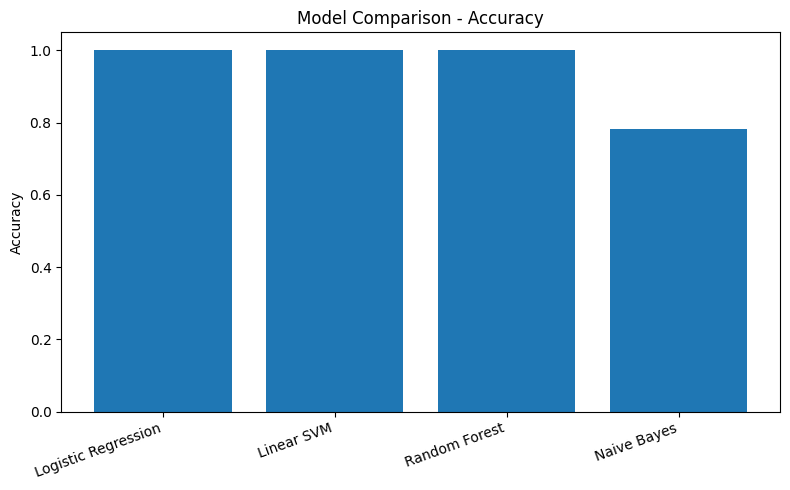

In [33]:

# Compare model accuracy visually

plt.figure(figsize=(8, 5))
plt.bar(results_df["model"], results_df["accuracy"])
plt.title("Model Comparison - Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


Best model: Logistic Regression
                 precision    recall  f1-score   support

  Likely_Return       1.00      1.00      1.00        25
Unlikely_Return       1.00      1.00      1.00         7

       accuracy                           1.00        32
      macro avg       1.00      1.00      1.00        32
   weighted avg       1.00      1.00      1.00        32



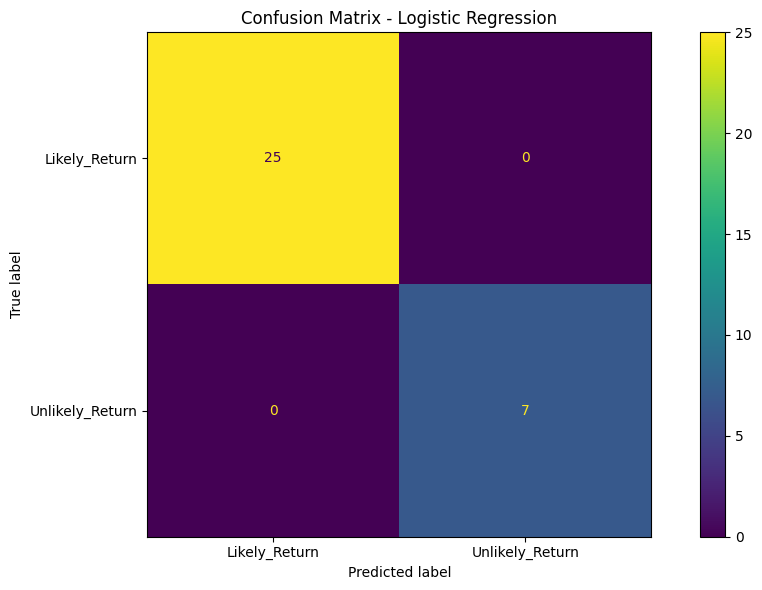

In [34]:

# Detailed evaluation for the best model

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_preds = best_model.predict(X_test_vec)

print("Best model:", best_model_name)
print(classification_report(y_test, best_preds, zero_division=0))

cm = confusion_matrix(y_test, best_preds, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


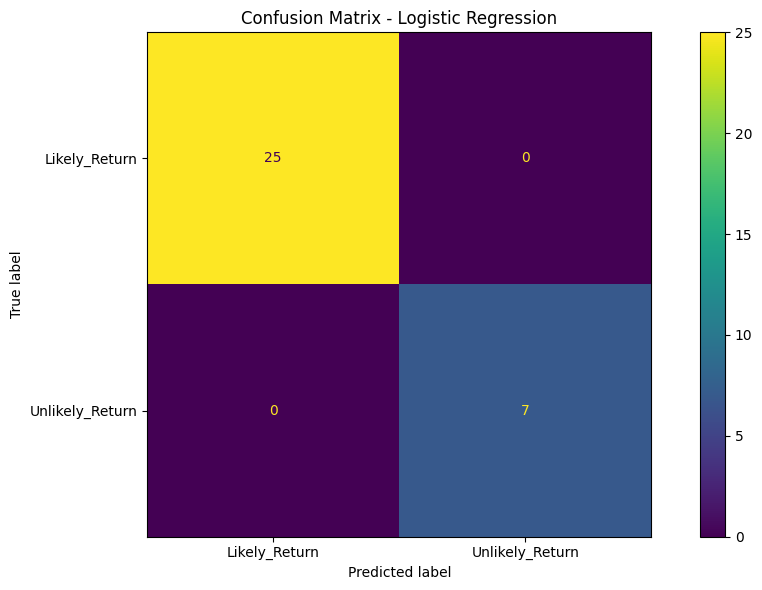

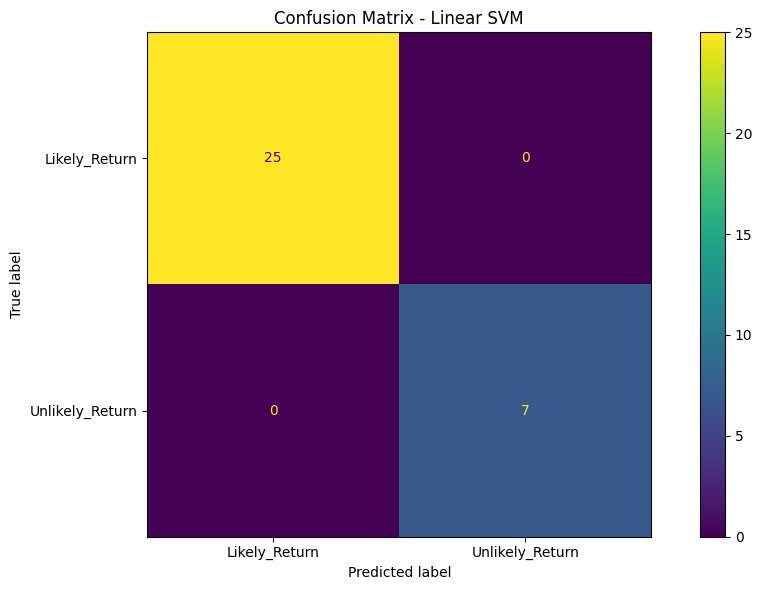

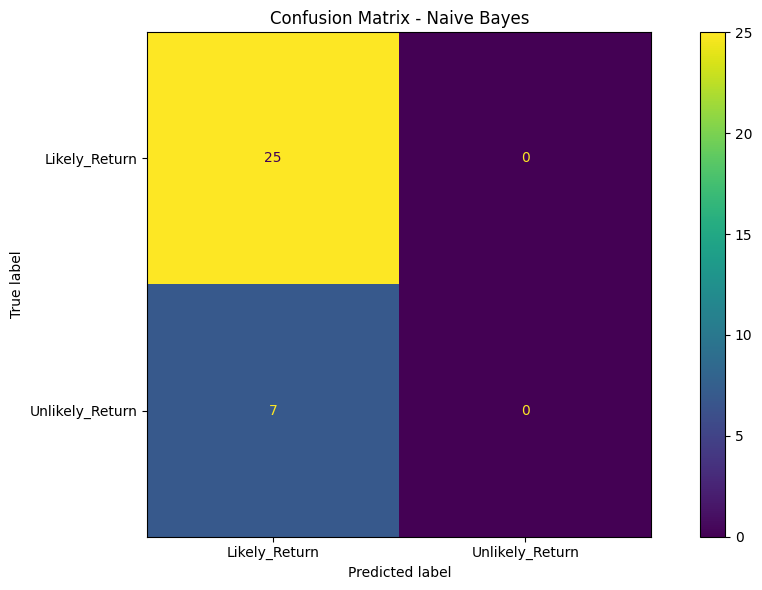

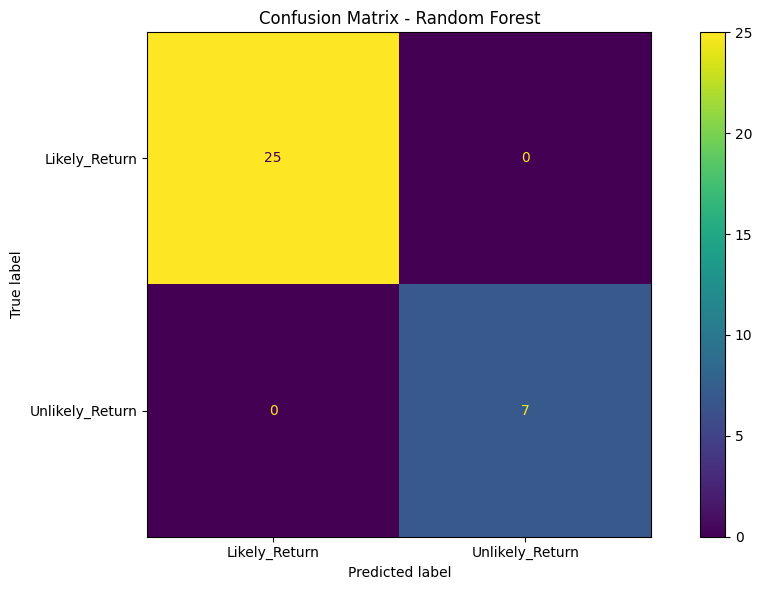

In [35]:

# Confusion matrices for all models

for name, model in trained_models.items():
    preds = model.predict(X_test_vec)
    cm = confusion_matrix(y_test, preds, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()


In [36]:

# Most important predictive terms (where available)

feature_names = vectorizer.get_feature_names_out()

if hasattr(best_model, "coef_"):
    coef = best_model.coef_[0]
    coef_df = pd.DataFrame({
        "term": feature_names,
        "coefficient": coef
    }).sort_values("coefficient")

    print("Terms pushing toward Unlikely_Return")
    display(coef_df.head(15))

    print("Terms pushing toward Likely_Return")
    display(coef_df.tail(15).sort_values("coefficient", ascending=False))

elif hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "term": feature_names,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    print("Top predictive terms based on feature importance")
    display(importance_df.head(20))

else:
    print("This model does not expose term-level feature importances directly.")


Terms pushing toward Unlikely_Return


,term,coefficient
98,definitely bring,-0.466934
39,bring,-0.466934
34,better value,-0.466934
33,better,-0.466934
526,value definitely,-0.466934
97,definitely,-0.429347
344,pricing feature,-0.423319
58,consider,-0.423319
406,returning,-0.423319
183,improves,-0.423319


Terms pushing toward Likely_Return


,term,coefficient
49,change improve,1.421460
407,right,1.421460
48,change,1.421460
408,right return,1.421460
404,return,1.421460
405,return change,1.421460
176,improve,1.421460
95,decision right,0.599341
303,optimistic right,0.553849
425,satisfied right,0.507692


## 12. Optional Export


In [37]:

# Export cleaned data and summary tables

analysis_df.to_csv(os.path.join(OUTPUT_DIR, "cleaned_analysis.csv"), index=False)
top_unigrams.to_csv(os.path.join(OUTPUT_DIR, "top_unigrams.csv"), index=False)
top_bigrams.to_csv(os.path.join(OUTPUT_DIR, "top_bigrams.csv"), index=False)
top_trigrams.to_csv(os.path.join(OUTPUT_DIR, "top_trigrams.csv"), index=False)
topics_df.to_csv(os.path.join(OUTPUT_DIR, "lda_topics.csv"), index=False)
cluster_keywords_df.to_csv(os.path.join(OUTPUT_DIR, "cluster_keywords.csv"), index=False)
results_df.to_csv(os.path.join(OUTPUT_DIR, "classification_model_results.csv"), index=False)

print("Exported files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print("-", f)


Exported files:
- classification_model_results.csv
- cleaned_analysis.csv
- cluster_keywords.csv
- lda_topics.csv
- top_bigrams.csv
- top_trigrams.csv
- top_unigrams.csv
